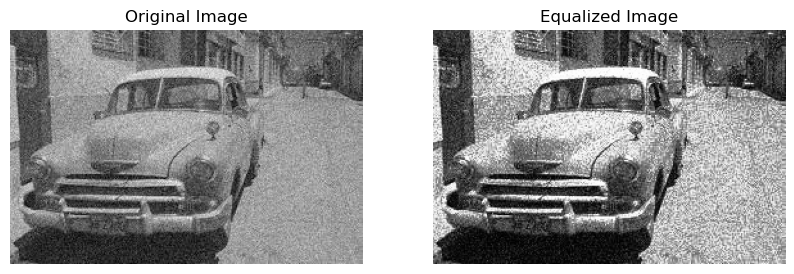

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
image = cv2.imread("D:/Wallpers/555.jfif", cv2.IMREAD_GRAYSCALE)

# Apply histogram equalization
equalized = cv2.equalizeHist(image)

# Show original and equalized images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Equalized Image")
plt.imshow(equalized, cmap='gray')
plt.axis('off')

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_9520\587258345.py:6: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(image.ravel(), 256, [0,256])
C:\Users\User\AppData\Local\Temp\ipykernel_9520\587258345.py:10: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(equalized.ravel(), 256, [0,256])


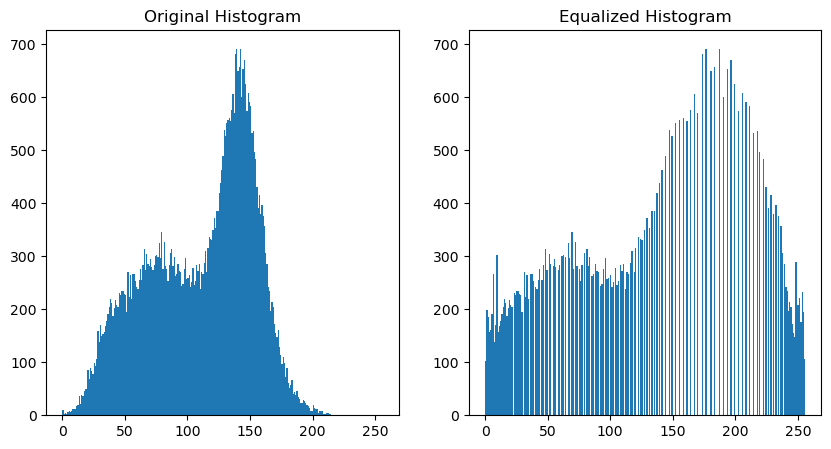

In [4]:
# Plot histograms
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Histogram")
plt.hist(image.ravel(), 256, [0,256])

plt.subplot(1,2,2)
plt.title("Equalized Histogram")
plt.hist(equalized.ravel(), 256, [0,256])

plt.show()

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
image = cv2.imread("D:/Wallpers/555.jfif", cv2.IMREAD_GRAYSCALE)

# Gaussian filters with different parameters
gauss_3 = cv2.GaussianBlur(image, (3,3), 0)
gauss_5 = cv2.GaussianBlur(image, (5,5), 0)
gauss_sigma2 = cv2.GaussianBlur(image, (5,5), 2)

In [7]:
box_5 = cv2.blur(image, (5,5))

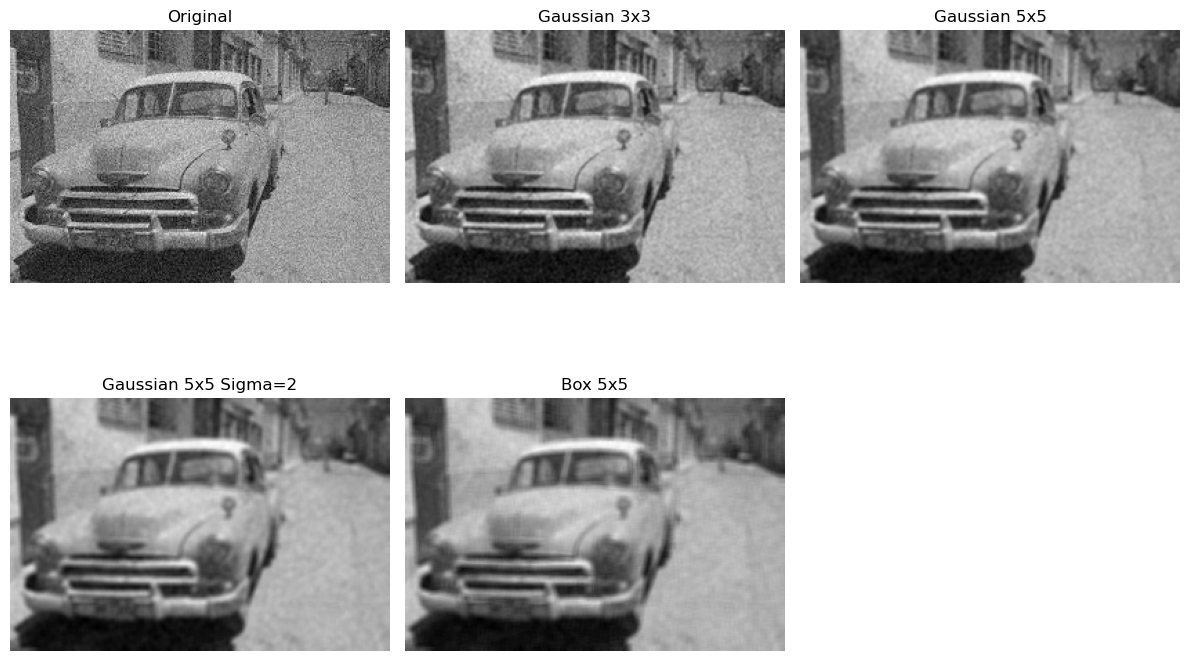

In [8]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.title("Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(2,3,2)
plt.title("Gaussian 3x3")
plt.imshow(gauss_3, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("Gaussian 5x5")
plt.imshow(gauss_5, cmap='gray')
plt.axis('off')

plt.subplot(2,3,4)
plt.title("Gaussian 5x5 Sigma=2")
plt.imshow(gauss_sigma2, cmap='gray')
plt.axis('off')

plt.subplot(2,3,5)
plt.title("Box 5x5")
plt.imshow(box_5, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

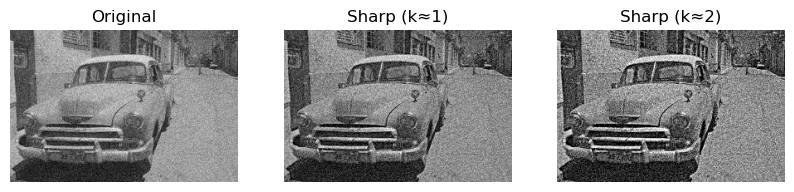

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("D:/Wallpers/555.jfif", cv2.IMREAD_GRAYSCALE)

# Step 1: Blur image
blurred = cv2.GaussianBlur(image, (9, 9), 10)

# Step 2 & 3: Unsharp masking using addWeighted
unsharp_1 = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)
unsharp_2 = cv2.addWeighted(image, 2.0, blurred, -1.0, 0)

# Show results
plt.figure(figsize=(10,6))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Sharp (k≈1)")
plt.imshow(unsharp_1, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Sharp (k≈2)")
plt.imshow(unsharp_2, cmap='gray')
plt.axis('off')

plt.show()

In [11]:
import numpy as np
import copy

def box_filt(n):
    if n <= 0 or n % 2 == 0:
        raise ValueError("Window size must be positive odd integer.")

    kernel = np.ones((n, n), np.float32) / (n * n)
    return kernel


def apply_filters(image_input, box, filt_size):

    pad_size = int(np.ceil(filt_size / 2))

    image_padded = np.pad(
        image_input,
        pad_width=((pad_size, pad_size), (pad_size, pad_size)),
        mode='symmetric'
    )

    image_box = copy.deepcopy(image_input)

    row, column = image_input.shape

    for i in range(row):
        for j in range(column):
            patch_curr = image_padded[i:i+filt_size, j:j+filt_size]
            results_box = box * patch_curr
            image_box[i, j] = np.sum(results_box)

    return image_box

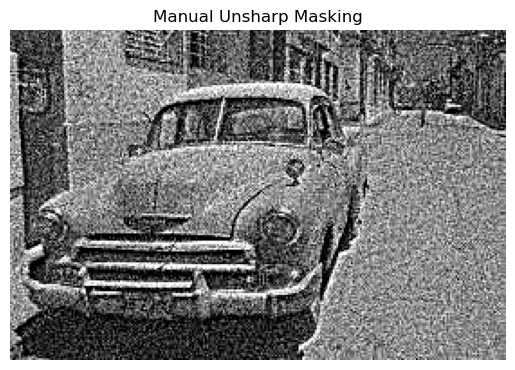

In [12]:
import cv2
import matplotlib.pyplot as plt

filt_size = 5
k = 2

image_input = cv2.imread("D:/Wallpers/555.jfif", 0).astype('float32') / 255

box = box_filt(filt_size)

image_blur = apply_filters(image_input, box, filt_size)

image_diff = image_input - image_blur

image_sharp = image_input + k * image_diff

image_sharp = np.clip(image_sharp, 0, 1)

plt.imshow(image_sharp, cmap='gray')
plt.title("Manual Unsharp Masking")
plt.axis('off')
plt.show()